<a href="https://colab.research.google.com/github/georgiy-zhdanov/a-teami-it548/blob/main/%D0%9F%D0%BE%D0%BB%D0%BD%D0%BE%D1%81%D0%B2%D1%8F%D0%B7%D0%BD%D1%8B%D0%B5_%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Создание полносвязной нейронной сети на PyTorch

In [ ]:
import torch
import torch.nn as nn # модуль для создания нейросети
import torch.optim as optim # модуль для выбора оптимизатора (Adam, SGD..)
from torchvision import datasets, transforms # модуль для загрузки и обработки датасета
from torch.utils.data import DataLoader # модуль для работы с данными, в данном случае мы импортировали загрузчик данных
from torchsummary import summary # модуль для вывода информации о модели
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

RuntimeError: Trying to override a python impl for DispatchKey.Autograd on operator aten::dropout

https://www.geeksforgeeks.org/python/how-to-normalize-images-in-pytorch/

https://www.mnist.org/#intro

https://researchdatapod.com/wp-content/uploads/2024/11/class_distribution.png.webp

## 1. Загрузка датасета

В этот раз мы будем работать с датасетом MNIST. MNIST dataset — это база данных, в которой хранятся образцы написания рукописных цифр в градациях серого цвета. Она состоит из 70 тысяч картинок одинакового размера, где изображены написанные от руки цифры от 0 до 9. Тренировочная выборка включает в себя 60_000 изображений, тестовая - 10_000.

Размер изображений - 28x28 пикселей. Пиксель представлен уровнем серого цвета (от 0 - черный, до 255 - белый).

Wikipedia: https://ru.wikipedia.org/wiki/MNIST_(база_данных)


**Внимание вопрос!**

1) Какая ML-задача будет решаться?
2) Какой вид обучения будет использоваться?
3) На фотографии (https://researchdatapod.com/wp-content/uploads/2024/11/class_distribution.png.webp)  показано количество примеров для каждого класса тренировочной выборки. Сбалансированы ли классы? Какие метрики можно использовать для оценки модели?



**Создание пайплайна преобразований входного изображения**

Каждое входное изображение датасета будет превращено в тензор и нормализовано с помщью функционала метода transform. Сначала изображение преобразуется в тензор, при этом насыщенность канала от 0 до 255 переходит в диапазон от 0 до 1.

Нормализация изображений — это преобразование, которое масштабирует значения пикселей, чтобы они имели заданное среднее значение (mean) и стандартное отклонение (std). Нормализация делает модель менее чувствительной к изменениям освещения, контраста или других факторов, улучшая обобщающую способность и позволяет нейронной сети обучаться быстрее.

Для MNIST среднее и стандартное отклонение равны 0.1307 и 0.3081 соответственно.

ToTensor (docs): https://docs.pytorch.org/vision/master/generated/torchvision.transforms.ToTensor.html

ToTensor: https://www.geeksforgeeks.org/python/converting-an-image-to-a-torch-tensor-in-python/

Normalize (docs): https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

Normalize: https://www.geeksforgeeks.org/python/how-to-normalize-images-in-pytorch/

Задача нормализации - привести все данные к одному виду. В частности нейросеть работает с числами от 0 до 1, поэтому нам требуется преобразовать их всех к этому диапозону

In [ ]:
# Преобразования: перевод в тензор и нормализация (среднее 0.5, std 0.5 для MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

**Скачивание датасета и создание DataLoader**

DataLoader (Загрузчик Данных) — это класс, который упрощает загрузку и перебор данных для обучения моделей глубокого обучения. Он обеспечивает функциональность для создания батчей, перемешивания и обработки данных, что упрощает работу с большими наборами данных. Весь процесс загрузки данных при обучении лежит на нём

In [ ]:
# Загрузка обучающего и тестового наборов
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader для батчей
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.38MB/s]


**Посмотрим на данные**

В ходе работы крайне полезно визуализировать данные. Для этого подходят фреймворки для визуализации: matplotlib, seaborn, plotly и т.п. Визуализируем
примеры из тренировочного набора и разметку к ним.

**Внимание вопрос!**

1) Как нормализованное изображение превратить в оригинальное?
2) Какое будет минимальное и максимальное значение в нормализованном датасете?

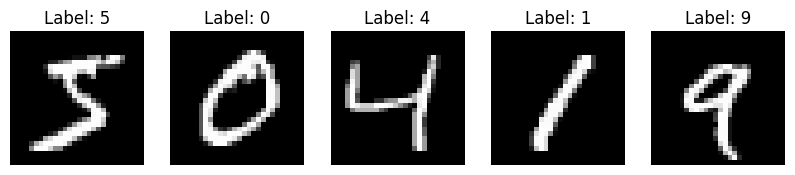

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    image, label = train_dataset[i]
    # Обратная нормализация для отображения (из [-1,1] в [0,1])
    image = image * 0.3081 + 0.1307
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.show()

## 2. Создание нейронной сети

Небольшое видео для домашнего просмотра: https://rutube.ru/video/8d1a7f3572ded7e5603a73f54e31264d/. Здесь разобран прямой проход по полносвязной нейронке и приведен хороший пример работы.

Перейдем к созданию полносвязной нейронной сети. Каждый нейрон такой сети связан с каждым нейроном предыдущего слоя.

Для создания сети надо унаследоваться от класса nn.Module,  а также заполнить методы __init__ и forward. В методе __init__ как правило прописываются используемые слои и сохраняется дополнительная информация. В методе forward реализуется прямой проход.

**Внимание вопрос!**

1) Что такое функция активации?
2) Как работает нейрон полносвязной сети?
3) Сколько нейронов нужно в выходном слое для нашей задачи?

Слой Flatten вытягивает изображение 28х28 в вектор из 784 пикселей.

In [ ]:
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.flatten = nn.Flatten()  # Разворачиваем 28x28 в 784
        self.fc1 = nn.Linear(784, 128)  # Первый скрытый слой
        self.fc2 = nn.Linear(128, 64)   # Второй скрытый слой
        self.fc3 = nn.Linear(64, 10)    # Выходной слой (10 классов цифр)
        self.relu = nn.ReLU()           # Функция активации

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Без активации на выходе, так как используем CrossEntropyLoss
        return x

model = FCNN()

# Визуализация: Показать архитектуру модели (текстовое описание или простой график)
print(model)
# Для простоты: текстовый вывод структуры

FCNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


**Внимание вопрос!**

Ниже приведено описание нейронной сети.

1) Сколько всего обучаемых параметров?
2) Сколько обучаемых параметров в первом полносвязном слое? Как получено это значение?

In [ ]:
summary(model.to("cuda"), input_size=(1, 784))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 64]           8,256
              ReLU-5                   [-1, 64]               0
            Linear-6                   [-1, 10]             650
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.42
Estimated Total Size (MB): 0.43
----------------------------------------------------------------


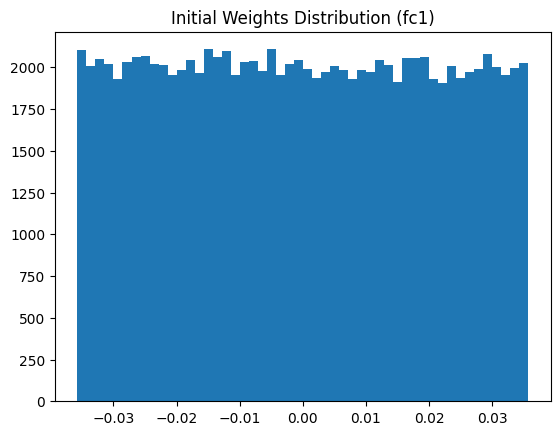

In [ ]:
# Гистограмма весов первого слоя
weights = model.fc1.weight.detach().cpu().numpy().flatten()
plt.hist(weights, bins=50)
plt.title('Initial Weights Distribution (fc1)')
plt.show()

## 3. Обучение нейронной сети

**Подготовка оптимизатора и функции потерь**

Оптимизатор нейросети — это алгоритм, который настраивает веса для достижения наилучшего результата при обучении модели. Он минимизирует функцию потерь, что позволяет модели точно предсказывать выходные данные. Оптимизаторы работают на основе алгоритмов градиентного спуска, которые позволяют находить локальные минимумы функции потерь. Наиболее распространенным оптимизатором в данный момент является Adam. Его будем и использовать.

Коэффициент скорости обучения (learning rate) – это гиперпараметр, определяющий порядок того, как мы будем корректировать наши весы с учётом функции потерь в градиентном спуске. Чем ниже величина, тем медленнее мы движемся по наклонной. Подробнее можно прочитать тут https://habr.com/ru/articles/469931/.

**Внимание вопрос!**

1) Чему равен коэффициент скорости обучения в нашем случае?

Функция потерь (loss function) является одним из ключевых понятий в обучении нейронных сетей. Она представляет собой математическую функцию, которая измеряет, насколько хорошо модель предсказывает целевую переменную по сравнению с истинными значениями. Таким образом, функция потерь позволяет оценить качество работы нейронной сети и использовать эту оценку для коррекции параметров модели.

Категориальная кросс-энтропия — это функция потерь, которая оценивает, насколько точно модель предсказывает класс в задачах многоклассовой классификации. Она сравнивает вероятность правильного ответа с прогнозами модели и наказывает за ошибки. Чем ближе предсказание к правильному классу, тем ниже будет значение функции потерь.

CE-loss документация: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

CE-loss разбор с примером: https://www.geeksforgeeks.org/deep-learning/categorical-cross-entropy-in-multi-class-classification/

Еще пример: https://365datascience.com/tutorials/machine-learning-tutorials/cross-entropy-loss/

Softmax: https://dzone.com/articles/understanding-softmax-activation-function

**Внимание вопрос!**

1) Рассчитать CE-loss при следующих входных данных. Вероятности на выходе из модели после применения softmax: [0.2, 0.2, 0.6]. One-hot правильного ответа: [0, 0, 1].

In [ ]:
criterion = nn.CrossEntropyLoss()  # Функция потерь для классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Оптимизатор Adam с learning rate 0.001

**Цикл обучения**

In [ ]:
num_epochs = 10  # Количество эпох
losses = []  # Для хранения потерь по эпохам

for epoch in range(num_epochs):
    model.train()  # Режим обучения
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()  # Обнуляем градиенты
        images = images.to("cuda")
        outputs = model(images)  # Прямой проход
        loss = criterion(outputs.cpu(), labels)  # Вычисляем потерю
        loss.backward()  # Обратный проход
        optimizer.step()  # Обновляем веса
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [1/10], Loss: 0.2682
Epoch [2/10], Loss: 0.1127
Epoch [3/10], Loss: 0.0778
Epoch [4/10], Loss: 0.0583
Epoch [5/10], Loss: 0.0476
Epoch [6/10], Loss: 0.0402
Epoch [7/10], Loss: 0.0321
Epoch [8/10], Loss: 0.0264
Epoch [9/10], Loss: 0.0255
Epoch [10/10], Loss: 0.0222


In [ ]:
losses

[0.2681556317859939,
 0.11270827411074263,
 0.07783533069890922,
 0.05825252445595367,
 0.0475564527533589,
 0.04016152172245637,
 0.032081220847169016,
 0.026396199807628685,
 0.025549594361231654,
 0.02215100003527785]

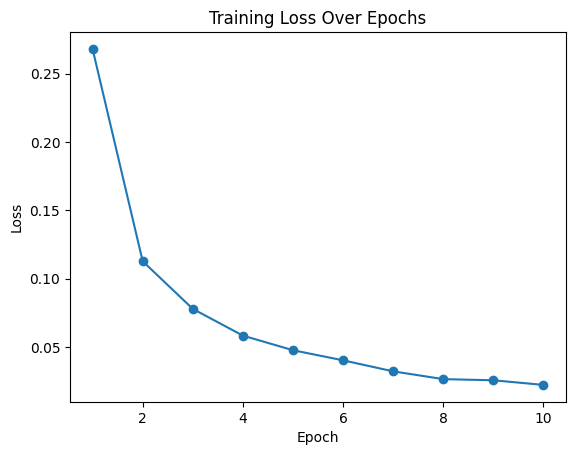

In [ ]:
# График функции потерь по эпохам
plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

**Внимание вопрос!**

1) Проанализируйте график функции потерь.

**ВАЖНО!**

Данный тренировочный цикл пока что не оптимален, мы обязательно улучшим его, добавив проверку нейронной сети на валидационной выборке! Это очень важно, т.к. помогает заметить и предотвратить переобучение нейронки, получить более полную оценку.

## 4. Оценка модели

Оценка модели происходит также как в классическом ML: модель делает предсказание тестовой выборки, а затем считаются метрики. Ниже приведены примеры подсчета различных метрик для оценки модели классификации.

In [ ]:
model.eval()  # Режим оценки
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():  # Отключаем градиенты для скорости
    for images, labels in test_loader:
        outputs = model(images.cuda())
        _, predicted = torch.max(outputs.data, 1)  # Индекс максимального значения
        total += labels.size(0)
        predicted = predicted.cpu()
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')

Accuracy on test set: 97.51%


In [ ]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.95      0.99      0.97      1010
           4       0.99      0.96      0.97       982
           5       0.99      0.96      0.97       892
           6       0.99      0.97      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.95      0.98      0.97       974
           9       0.95      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.98      0.98      0.98     10000



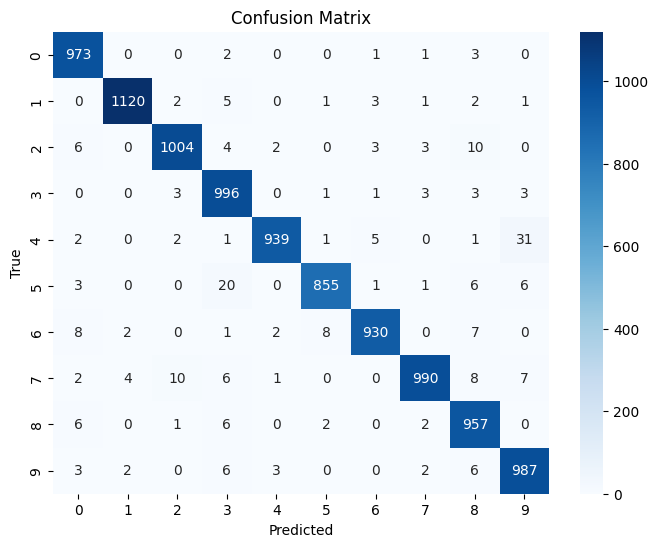

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


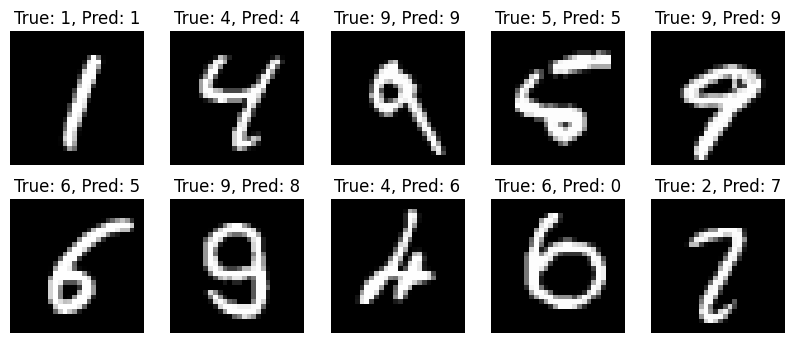

In [ ]:
# Примеры предсказаний (правильные и неправильные)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
correct_indices = [i for i in range(len(all_preds)) if all_preds[i] == all_labels[i]][5:10]
wrong_indices = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]][5:10]

for i, idx in enumerate(correct_indices):
    image, label = test_dataset[idx]
    image = image * 0.5 + 0.5
    axes[0, i].imshow(image.squeeze(), cmap='gray')
    axes[0, i].set_title(f'True: {label}, Pred: {all_preds[idx]}')
    axes[0, i].axis('off')

for i, idx in enumerate(wrong_indices):
    image, label = test_dataset[idx]
    image = image * 0.5 + 0.5
    axes[1, i].imshow(image.squeeze(), cmap='gray')
    axes[1, i].set_title(f'True: {label}, Pred: {all_preds[idx]}')
    axes[1, i].axis('off')

plt.show()

**Внимание вопрос!**

1) Хорошо ли обучилась модель?
2) Проанализируйте неправильно предсказанные сэмплы.

## 5. Сохранение модели

In [ ]:
torch.save(model.state_dict(), 'mnist_model.pth')
print('Model saved to mnist_model.pth')

Model saved to mnist_model.pth


# Для работы в классе

Поэксперементируйте с гиперпараметрами и архитектурой нейронной сети для получения лучшего результата. Сделайте предположения, что позволило улучшить результат.

# Для самостоятельной тренировки дома

Обучите полносвязную нейронную сеть на датасете Fashion MNIST. По ссылке доступен код подгрузки из напрямую торча.

https://www.geeksforgeeks.org/deep-learning/how-to-load-fashion-mnist-dataset-using-pytorch/

# Домашнее задание: FashionMNIST

In [ ]:
import torch
import torch.nn as nn # модуль для создания нейросети
import torch.optim as optim # модуль для выбора оптимизатора (Adam, SGD..)
from torchvision import datasets, transforms # модуль для загрузки и обработки датасета
from torch.utils.data import DataLoader # модуль для работы с данными, в данном случае мы импортировали загрузчик данных
from torchsummary import summary # модуль для вывода информации о модели
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [ ]:
#В массив - ToTensor, Нормализация - Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


In [ ]:
# Загрузка обучающего и тестового наборов
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader для батчей
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.72MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.8MB/s]


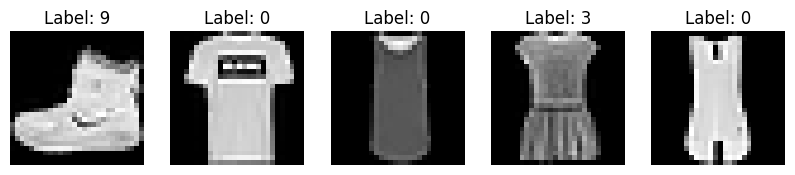

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    image, label = train_dataset[i]
    # Обратная нормализация для отображения (из [-1,1] в [0,1])
    image = image * 0.3081 + 0.1307
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.show()

1. В следующем блоке, можно считат, что мы КАЖДЫЙ ИЗ 128 нейронов:
nn.Linear(784, **128**) этого слоя, соединяем с 784 nn.Linear(**784**, 128) прошлого слоя.
2. self.fc1 = nn.Linear(784, 128) это **второй** по счёту слой из всех, и **первый скрытый.**

ПУНКТ - НЕЙРОСЕТЬ

In [ ]:
class FCNN(nn.Module):
  def __init__(self):
    super(FCNN, self).__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(784, 128)  # Первый скрытый слой
    self.fc2 = nn.Linear(128, 64)   # Второй скрытый слой
    self.fc3 = nn.Linear(64, 10)    # Выходной слой (10 классов цифр)
    self.relu = nn.ReLU()
  def forward(self, x):
    x = self.flatten(x)
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)  # Без активации на выходе, так как используем CrossEntropyLoss
    return x

model = FCNN() # В следующей строке кода выведем model поместив объект класса FCNN сюда в model

# Визуализация: Показать архитектуру модели (текстовое описание или простой график)
print(model)
# Для простоты: текстовый вывод структуры

FCNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [ ]:
summary(model.to("cuda"), input_size=(1, 784))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 64]           8,256
              ReLU-5                   [-1, 64]               0
            Linear-6                   [-1, 10]             650
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.42
Estimated Total Size (MB): 0.43
----------------------------------------------------------------


In [ ]:
ПУНКТ - ОБУЧЕНИЕ

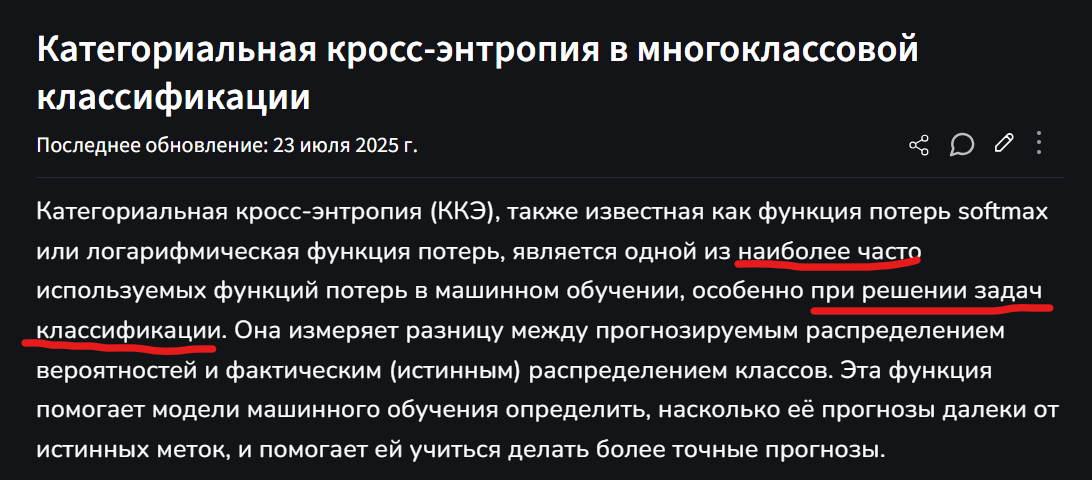

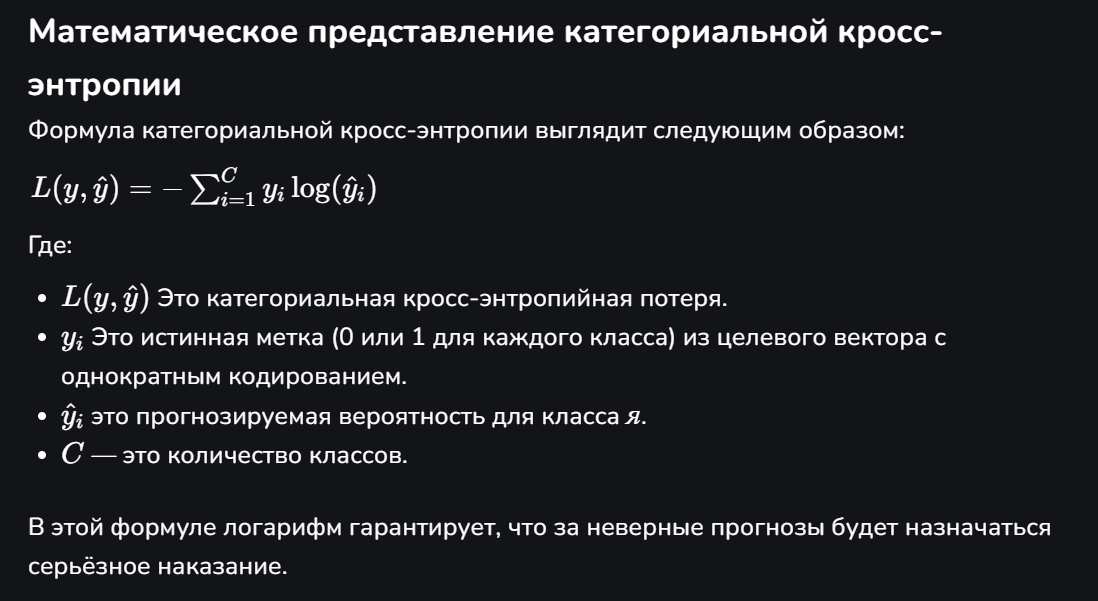

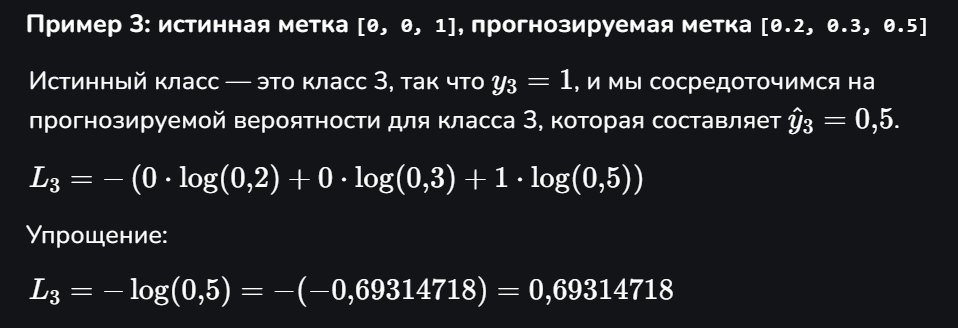

In [ ]:
criterion = nn.CrossEntropyLoss()  # Функция потерь для классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Оптимизатор Adam с learning rate 0.001

In [ ]:
num_epochs = 10  # Количество эпох
losses = []  # Для хранения потерь по эпохам

for epoch in range(num_epochs):
    model.train()  # Режим обучения
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()  # Обнуляем градиенты
        images = images.to("cuda")
        outputs = model(images)  # Прямой проход
        loss = criterion(outputs.cpu(), labels)  # Вычисляем потерю
        loss.backward()  # Обратный проход
        optimizer.step()  # Обновляем веса
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [1/10], Loss: 0.4765
Epoch [2/10], Loss: 0.3497
Epoch [3/10], Loss: 0.3134
Epoch [4/10], Loss: 0.2891
Epoch [5/10], Loss: 0.2723
Epoch [6/10], Loss: 0.2561
Epoch [7/10], Loss: 0.2450
Epoch [8/10], Loss: 0.2342
Epoch [9/10], Loss: 0.2208
Epoch [10/10], Loss: 0.2114


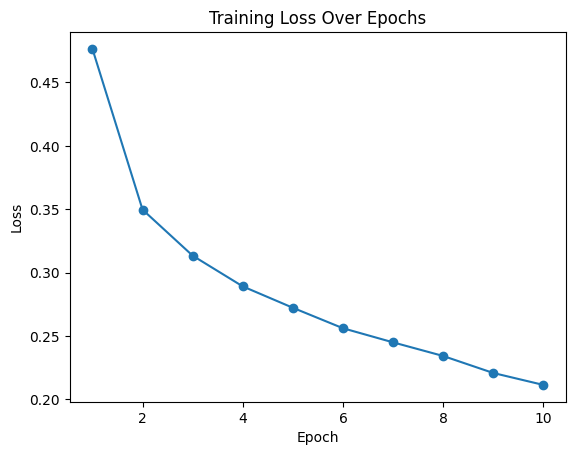

In [ ]:
# График функции потерь по эпохам
plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

ОЦЕНКА

In [ ]:
model.eval()  # Режим оценки
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():  # Отключаем градиенты для скорости
    for images, labels in test_loader:
        outputs = model(images.cuda())
        _, predicted = torch.max(outputs.data, 1)  # Индекс максимального значения
        total += labels.size(0)
        predicted = predicted.cpu()
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')

Accuracy on test set: 88.43%


In [ ]:
torch.save(model.state_dict(), 'mnist_fashion_model.pth')
print('Model saved to mnist_fashion_model.pth')

Model saved to mnist_fashion_model.pth


Попробуем протестить на своих примерах

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
import os

# Названия классов FashionMNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def download_from_drive_url(drive_url):
    """
    Скачивает изображение с Google Drive по ссылке общего доступа
    """
    try:
        # Преобразуем ссылку общего доступа в прямую ссылку для скачивания
        file_id = drive_url.split('/d/')[1].split('/')[0]
        direct_url = f"https://drive.google.com/uc?id={file_id}"

        # Скачиваем файл
        response = requests.get(direct_url)
        response.raise_for_status()

        # Открываем изображение из байтов
        image = Image.open(BytesIO(response.content))
        return image

    except Exception as e:
        print(f"Ошибка при скачивании: {e}")
        return None

def predict_custom_image(model, image_path_or_url):
    """
    Загружает ваше изображение из файла или URL, преобразует в формат MNIST и делает предсказание
    """
    model.eval()

    try:
        image = None

        # Проверяем, это URL Google Drive или локальный путь
        if image_path_or_url.startswith('http'):
            print("📥 Обнаружена ссылка, скачиваю изображение...")
            image = download_from_drive_url(image_path_or_url)
            if image is None:
                return None, None
        else:
            # Локальный файл
            if not os.path.exists(image_path_or_url):
                print(f"❌ Файл не найден: {image_path_or_url}")
                return None, None
            image = Image.open(image_path_or_url)

        print(f"✅ Изображение загружено")
        print(f"📐 Исходный размер: {image.size}, режим: {image.mode}")

        # Показываем оригинальное изображение
        plt.figure(figsize=(12, 4))

        # Оригинальное изображение
        plt.subplot(1, 3, 1)
        if image.mode == 'L':
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(image)
        plt.title('Оригинальное изображение')
        plt.axis('off')

        # Преобразования для MNIST
        transform = transforms.Compose([
            transforms.Resize((28, 28)),          # Ресайз до 28x28
            transforms.Grayscale(num_output_channels=1),  # Конвертация в ч/б
            transforms.ToTensor(),                # В тензор
            transforms.Normalize((0.1307,), (0.3081,))  # Нормализация как в MNIST
        ])

        # Применяем преобразования
        image_tensor = transform(image)
        print(f"📏 Размер после преобразований: {image_tensor.shape}")

        # Подготовка для модели (добавляем batch dimension)
        image_batch = image_tensor.unsqueeze(0).to("cuda")

        # Предсказание
        with torch.no_grad():
            output = model(image_batch)
            probabilities = torch.softmax(output.cpu(), dim=1)
            predicted_label = torch.argmax(output, dim=1).cpu().item()
            confidence = probabilities[0][predicted_label].item()

        # Преобразование для отображения (обратная нормализация)
        display_image = image_tensor.squeeze() * 0.3081 + 0.1307

        # Преобразованное изображение
        plt.subplot(1, 3, 2)
        plt.imshow(display_image, cmap='gray')
        plt.title('После преобразований\n(28x28, ч/б, нормализация)')
        plt.axis('off')

        # График вероятностей
        plt.subplot(1, 3, 3)
        colors = ['red' if i == predicted_label else 'blue' for i in range(10)]
        plt.barh(class_names, probabilities[0].numpy(), color=colors)
        plt.xlabel('Вероятность')
        plt.title('Предсказания модели')
        plt.tight_layout()
        plt.show()

        # Вывод результатов
        print(f"\n🎯 РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ:")
        print(f"Предсказанный класс: {predicted_label} - {class_names[predicted_label]}")
        print(f"Уверенность: {confidence:.4f} ({confidence*100:.2f}%)")

        # Топ-3 предсказания
        top3_probs, top3_indices = torch.topk(probabilities[0], 3)
        print(f"\n🏆 ТОП-3 ПРЕДСКАЗАНИЯ:")
        for i, (prob, idx) in enumerate(zip(top3_probs, top3_indices)):
            print(f"{i+1}. {class_names[idx.item()]}: {prob.item():.4f} ({prob.item()*100:.2f}%)")

        return predicted_label, probabilities

    except Exception as e:
        print(f"❌ Ошибка при обработке изображения: {e}")
        return None, None

# Функция для интерактивного тестирования
def interactive_image_testing(model):
    """
    Интерактивный режим для тестирования ваших изображений
    """
    print("🔍 РЕЖИМ ТЕСТИРОВАНИЯ ВАШИХ ИЗОБРАЖЕНИЙ")
    print("=" * 50)
    print("Поддерживаются:")
    print("• Локальные файлы: C:/path/to/image.jpg или ./image.png")
    print("• Ссылки Google Drive: https://drive.google.com/...")

    while True:
        print("\nВыберите действие:")
        print("1 - Протестировать изображение")
        print("2 - Выйти")

        choice = input("Ваш выбор (1-2): ").strip()

        if choice == '1':
            image_path = input("Введите путь к изображению или ссылку Google Drive: ").strip()

            # Убираем кавычки если они есть
            image_path = image_path.strip('"\'')

            predict_custom_image(model, image_path)

        elif choice == '2':
            print("Выход из режима тестирования.")
            break
        else:
            print("❌ Неверный выбор! Попробуйте снова.")

In [ ]:
predict_custom_image(model, "https://yandex.ru/images/search?family=yes&img_url=https%3A%2F%2Fwww.svgrepo.com%2Fshow%2F2060%2Fshirt.svg&lr=10719&p=3&pos=31&rpt=simage&source=serp&stype=image&text=картинка%20одежды")

📥 Обнаружена ссылка, скачиваю изображение...
Ошибка при скачивании: list index out of range


(None, None)

# Эксперимент: Скрытыи слои


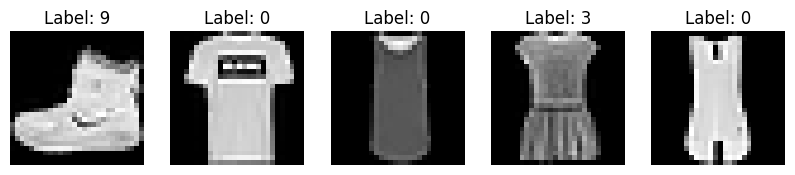

In [ ]:
import torch
import torch.nn as nn # модуль для создания нейросети
import torch.optim as optim # модуль для выбора оптимизатора (Adam, SGD..)
from torchvision import datasets, transforms # модуль для загрузки и обработки датасета
from torch.utils.data import DataLoader # модуль для работы с данными, в данном случае мы импортировали загрузчик данных
from torchsummary import summary # модуль для вывода информации о модели
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
#В массив - ToTensor, Нормализация - Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
# Загрузка обучающего и тестового наборов
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader для батчей
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    image, label = train_dataset[i]
    # Обратная нормализация для отображения (из [-1,1] в [0,1])
    image = image * 0.3081 + 0.1307
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.show()


In [ ]:
class FCNN(nn.Module):
  def __init__(self):
    super(FCNN, self).__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(784, 256)  # Первый скрытый слой
    self.fc2 = nn.Linear(256, 128)   # Второй скрытый слой
    self.fc3 = nn.Linear(128, 64)    #Третий скрытый слой
    self.fc4 = nn.Linear(64, 10)    # Выходной слой (10 классов цифр)
    self.relu = nn.ReLU()
  def forward(self, x):
    x = self.flatten(x)
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.relu(self.fc3(x))
    x = self.fc4(x)  # Без активации на выходе, так как используем CrossEntropyLoss
    return x

model = FCNN() # В следующей строке кода выведем model поместив объект класса FCNN сюда в model

# Визуализация: Показать архитектуру модели (текстовое описание или простой график)
print(model)
# Для простоты: текстовый вывод структуры

FCNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [ ]:
summary(model.to("cuda"), input_size=(1, 784))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
            Linear-4                  [-1, 128]          32,896
              ReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 64]           8,256
              ReLU-7                   [-1, 64]               0
            Linear-8                   [-1, 10]             650
Total params: 242,762
Trainable params: 242,762
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.93
Estimated Total Size (MB): 0.94
----------------------------------------------------------------


In [ ]:
criterion = nn.CrossEntropyLoss()  # Функция потерь для классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Оптимизатор Adam с learning rate 0.001

In [ ]:
num_epochs = 25  # Количество эпох
losses = []  # Для хранения потерь по эпохам

for epoch in range(num_epochs):
    model.train()  # Режим обучения
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()  # Обнуляем градиенты
        images = images.to("cuda")
        outputs = model(images)  # Прямой проход
        loss = criterion(outputs.cpu(), labels)  # Вычисляем потерю
        loss.backward()  # Обратный проход
        optimizer.step()  # Обновляем веса
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [1/25], Loss: 0.4773
Epoch [2/25], Loss: 0.3484
Epoch [3/25], Loss: 0.3130
Epoch [4/25], Loss: 0.2886
Epoch [5/25], Loss: 0.2700
Epoch [6/25], Loss: 0.2521
Epoch [7/25], Loss: 0.2441
Epoch [8/25], Loss: 0.2296
Epoch [9/25], Loss: 0.2182
Epoch [10/25], Loss: 0.2096
Epoch [11/25], Loss: 0.2006
Epoch [12/25], Loss: 0.1910
Epoch [13/25], Loss: 0.1817
Epoch [14/25], Loss: 0.1742
Epoch [15/25], Loss: 0.1696
Epoch [16/25], Loss: 0.1623
Epoch [17/25], Loss: 0.1556
Epoch [18/25], Loss: 0.1492
Epoch [19/25], Loss: 0.1441
Epoch [20/25], Loss: 0.1410
Epoch [21/25], Loss: 0.1394
Epoch [22/25], Loss: 0.1310
Epoch [23/25], Loss: 0.1268
Epoch [24/25], Loss: 0.1253
Epoch [25/25], Loss: 0.1204


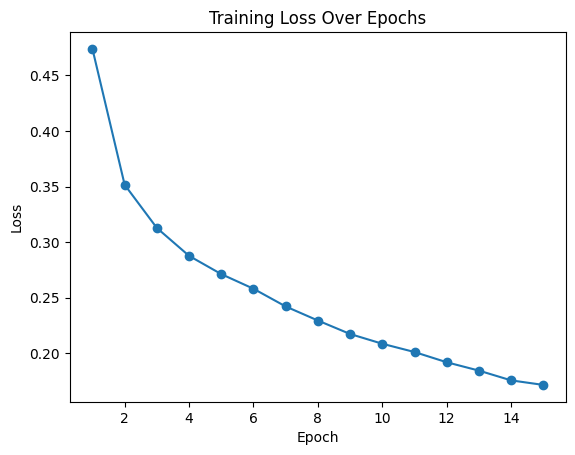

In [ ]:
# График функции потерь по эпохам
plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
model.eval()  # Режим оценки
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():  # Отключаем градиенты для скорости
    for images, labels in test_loader:
        outputs = model(images.cuda())
        _, predicted = torch.max(outputs.data, 1)  # Индекс максимального значения
        total += labels.size(0)
        predicted = predicted.cpu()
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')

NameError: name 'model' is not defined